In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d camnugent/sandp500
!unzip sandp500.zip

Dataset URL: https://www.kaggle.com/datasets/camnugent/sandp500
License(s): CC0-1.0
100% 19.3M/19.3M [00:00<00:00, 77.8MB/s]

Archive:  sandp500.zip
  inflating: all_stocks_5yr.csv      
  inflating: getSandP.py             
  inflating: individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._.DS_Store  
  inflating: individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._AAPL_data.csv  
  inflating: individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._ABC_data.csv  
  inflating: individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._A_data.csv  
  inflating: individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._MAS_data.csv  
  inflating: individual_stocks_5yr/individual_stocks_5yr/.DS_Store  
  inflating: individual_stocks_5yr/individual_stocks_5yr/AAL_data.csv  
  inflating: individual_stocks_5yr/individual_stocks_5yr/AAPL_data.csv  
  inflating: individual_stocks_5yr/individual_stocks_5yr/AAP_data.csv  
  inflating: individual_stocks_5yr/individual_stocks_5yr/ABBV_data.csv  
  inf

/tmp/ipykernel_8049/2672185682.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple['date'] = pd.to_datetime(apple['date'])


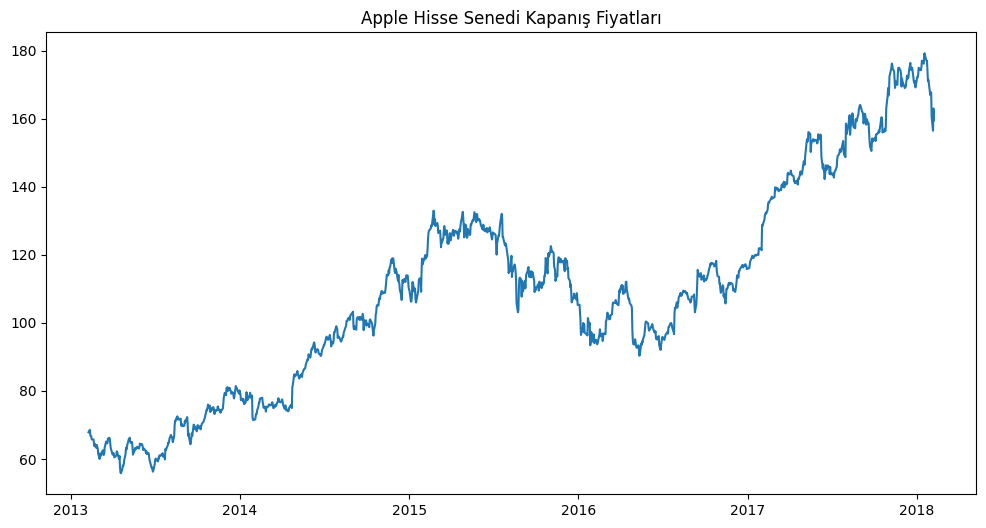

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku (Kaggle'dan indirdiğimiz dosya adı genellikle all_stocks_5yr.csv'dir)
df = pd.read_csv('all_stocks_5yr.csv')

# Sadece Apple (AAPL) hissesini seçelim ki kafamız karışmasın
apple = df[df['Name'] == 'AAPL']

# Tarih sütununu düzeltelim ve grafiğe dökelim
apple['date'] = pd.to_datetime(apple['date'])
plt.figure(figsize=(12,6))
plt.plot(apple['date'], apple['close'])
plt.title('Apple Hisse Senedi Kapanış Fiyatları')
plt.show()

In [3]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Sayıları 0-1 arasına sıkıştıralım
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(apple['close'].values.reshape(-1,1))

# 2. "Pencere" oluşturma: Son 60 günü kullanarak bir sonraki günü tahmin edeceğiz
prediction_days = 60
x_train = []
y_train = []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x-prediction_days:x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

# Veriyi derin öğrenme modelinin istediği şekle (format) sokalım
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("Veri hazır! Bilgisayar artık öğrenmeye başlayabilir.")

Veri hazır! Bilgisayar artık öğrenmeye başlayabilir.


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Modeli oluşturuyoruz
model = Sequential()

# İlk LSTM katmanı (Verideki desenleri öğrenir)
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
# Dropout: Bazı nöronları rastgele kapatır. Bu "belirsizlik" için kritik!
model.add(Dropout(0.2))

# İkinci LSTM katmanı
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Çıkış katmanı: Bize bir fiyat tahmini verir
model.add(Dense(units=1))

# Modeli derleyelim (Hata payını nasıl hesaplayacağını öğretiyoruz)
model.compile(optimizer='adam', loss='mean_squared_error')

# EĞİTİM BAŞLASIN: Bilgisayar veriye bakarak öğrenmeye başlıyor
# Bu işlem bilgisayarın hızına göre 1-2 dakika sürebilir.
model.fit(x_train, y_train, epochs=25, batch_size=32)

print("Model eğitimi tamamlandı! Artık tahmin yapmaya hazırız.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0387
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0036
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0036
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0036
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0034
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0032
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0031
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0033
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0033
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0027
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0025
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0026
Epoch 13/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0025
Epoch 14/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0024
Epoch 15/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0025
Epoc

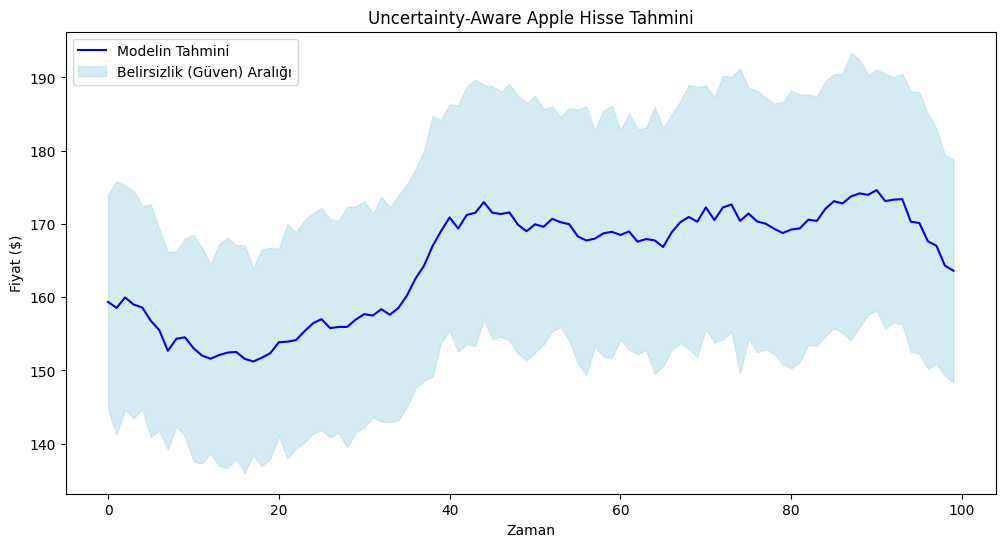

In [5]:
import matplotlib.pyplot as plt

# 1. Modeli "Belirsizlik Modu"nda çalıştıran fonksiyon
# Modeli 100 kez çalıştırıp 100 farklı tahmin alıyoruz
tahmin_sayisi = 100
tahminler = []

for i in range(tahmin_sayisi):
    # Modelin içindeki bazı nöronları rastgele kapatarak tahmin alıyoruz
    tahmin = model(x_train[-100:], training=True)
    tahminler.append(scaler.inverse_transform(tahmin))

tahminler = np.array(tahminler)

# 2. İstatistikleri hesaplayalım
ortalama_tahmin = tahminler.mean(axis=0) # 100 tahminin ortalaması (Ana tahminimiz)
standart_sapma = tahminler.std(axis=0)    # Tahminler arasındaki fark (Belirsizlik miktarı)

# 3. GÖRSELLEŞTİRME: Hocanın en çok bakacağı yer burası!
plt.figure(figsize=(12,6))

# Gerçek fiyatları çizelim
plt.plot(ortalama_tahmin, color='blue', label='Modelin Tahmini')

# Belirsizlik Aralığını (Gölgeyi) çizelim
# Ortalama tahminin üstüne ve altına standart sapmayı ekleyip çıkarıyoruz
plt.fill_between(
    range(len(ortalama_tahmin)),
    (ortalama_tahmin - 2 * standart_sapma).flatten(),
    (ortalama_tahmin + 2 * standart_sapma).flatten(),
    color='lightblue', alpha=0.5, label='Belirsizlik (Güven) Aralığı'
)

plt.title('Uncertainty-Aware Apple Hisse Tahmini')
plt.xlabel('Zaman')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.show()